In [1]:
import pandas as pd
import numpy as np
import dask.dataframe as dd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

import os
from glob import glob
from dask.array.image import imread
# image_location = "/data/jfreuden/SomeSkyImages/"
# enriched_df_location = "/data/jfreuden/allsky-light-pollution-simple/data/enriched.parquet"
image_location = "/home/rainybyte/SomeSkyImages/"
enriched_df_location = "/home/rainybyte/Downloads/enriched_df.parquet"

In [2]:
def plot_brightness(input_df, title_suffix=None):
    df = input_df[["timestamp", "image_mean", "image_std", "exposure"]].copy()
    plot_df = df.groupby(df["timestamp"].dt.date).agg(
        mean_image_mean=("image_mean", "mean"),
        n=("image_mean", "size"),
        pooled_image_std=("image_std", lambda s: np.sqrt(np.mean(s ** 2))),
    ).reset_index().rename(columns={"timestamp": "date"})
    plot_df["error"] = plot_df["pooled_image_std"] / np.sqrt(plot_df["n"])
    plot_df["date"] = pd.to_datetime(plot_df["date"], errors="coerce")
    plot_df = plot_df.dropna(subset=["date", "mean_image_mean", "error"]).sort_values("date")

    # Use matplotlib-friendly date numbers
    x = mdates.date2num(np.array(plot_df["date"]))
    y = plot_df["mean_image_mean"].to_numpy(dtype=float)
    yerr = plot_df["error"].to_numpy(dtype=float)

    # Weighted linear regression: y = m*x + b
    w = 1.0 / np.square(yerr)
    X = np.column_stack([x, np.ones_like(x)])
    W = np.diag(w)

    beta = np.linalg.inv(X.T @ W @ X) @ (X.T @ W @ y)
    m, b = beta

    # Fit on a dense grid
    x_grid = np.linspace(x.min(), x.max(), 400)
    X_grid = np.column_stack([x_grid, np.ones_like(x_grid)])
    y_grid = X_grid @ beta

    # Confidence band for the mean fit
    y_fit_obs = X @ beta
    dof = len(x) - 2
    s2 = np.sum(w * (y - y_fit_obs) ** 2) / dof
    cov_beta = s2 * np.linalg.inv(X.T @ W @ X)

    y_var_grid = np.sum(X_grid @ cov_beta * X_grid, axis=1)
    y_se_grid = np.sqrt(y_var_grid)

    z = 1.96
    y_lower = y_grid - z * y_se_grid
    y_upper = y_grid + z * y_se_grid

    # Plot dates
    dates_grid = mdates.num2date(x_grid)

    fig, ax = plt.subplots(figsize=(12, 5))

    ax.errorbar(
        plot_df["date"],
        y,
        yerr=yerr,
        fmt="o",
        markersize=3,
        capsize=3,
        alpha=0.5,
        label="Daily mean ± error",
    )

    ax.plot(
        dates_grid,
        y_grid,
        color="red",
        linewidth=2,
        label=f"Weighted fit: y = {m:.4g}x + {b:.4g}",
    )

    ax.fill_between(
        dates_grid,
        y_lower,
        y_upper,
        color="red",
        alpha=0.2,
        label="95% confidence band",
    )

    ax.set_xlabel("Date")
    ax.set_ylabel("Avg daily image brightness")

    suffix = "" if title_suffix == "" or title_suffix is None else f" ({title_suffix})"

    plt.title("Nightly image brightness" + suffix)
    ax.legend()
    fig.tight_layout()

def plot_exposure(input_df, title_suffix=None):
    df = input_df[["timestamp", "image_mean", "image_std", "exposure"]].copy()

    exposure_daily = df.groupby(df["timestamp"].dt.date).agg(
        mean_exposure=("exposure", "mean"),
        n=("exposure", "size"),
        exposure_std=("exposure", "std"),
    ).reset_index().rename(columns={"timestamp": "date"})

    exposure_daily["date"] = pd.to_datetime(exposure_daily["date"], errors="coerce")
    exposure_daily = exposure_daily.dropna(subset=["date", "mean_exposure"]).sort_values("date")

    # Error propagation for the mean of n observations:
    # sigma_mean = sqrt(sigma_1^2 + ... + sigma_n^2) / n
    # If each observation is represented by the within-night sample std,
    # then this reduces to exposure_std / sqrt(n).
    exposure_daily["error"] = exposure_daily["exposure_std"] / np.sqrt(exposure_daily["n"])

    plot_df = exposure_daily.copy()
    plot_df = plot_df.dropna(subset=["error"])
    x = mdates.date2num(np.array(plot_df["date"]))
    y = plot_df["mean_exposure"].to_numpy(dtype=float)
    yerr = plot_df["error"].to_numpy(dtype=float)

    # Weighted linear regression: y = m*x + b
    # Guard against zero or invalid error bars
    yerr_fit = np.where(yerr > 0, yerr, np.nan)
    valid = np.isfinite(x) & np.isfinite(y) & np.isfinite(yerr_fit)
    x_fit_data = x[valid]
    y_fit_data = y[valid]
    yerr_fit_data = yerr_fit[valid]

    w = 1.0 / np.square(yerr_fit_data)
    X = np.column_stack([x_fit_data, np.ones_like(x_fit_data)])
    W = np.diag(w)

    beta = np.linalg.inv(X.T @ W @ X) @ (X.T @ W @ y_fit_data)
    m, b = beta

    # Dense grid for line and confidence band
    x_grid = np.linspace(x_fit_data.min(), x_fit_data.max(), 400)
    X_grid = np.column_stack([x_grid, np.ones_like(x_grid)])
    y_grid = X_grid @ beta

    # Confidence band for the mean fit
    y_fit_obs = X @ beta
    dof = len(x_fit_data) - 2
    s2 = np.sum(w * (y_fit_data - y_fit_obs) ** 2) / dof
    cov_beta = s2 * np.linalg.inv(X.T @ W @ X)

    y_var_grid = np.sum(X_grid @ cov_beta * X_grid, axis=1)
    y_se_grid = np.sqrt(y_var_grid)

    z = 1.96
    y_lower = y_grid - z * y_se_grid
    y_upper = y_grid + z * y_se_grid

    dates_grid = mdates.num2date(x_grid)

    fig, ax = plt.subplots(figsize=(12, 5))

    ax.errorbar(
        plot_df["date"],
        y,
        yerr=yerr,
        fmt="o",
        markersize=3,
        capsize=3,
        alpha=0.6,
        label="Nightly mean exposure ± error",
    )

    ax.plot(
        dates_grid,
        y_grid,
        color="red",
        linewidth=2,
        label=f"Weighted fit: y = {m:.4g}x + {b:.4g}",
    )

    ax.fill_between(
        dates_grid,
        y_lower,
        y_upper,
        color="red",
        alpha=0.2,
        label="95% confidence band",
    )

    ax.set_xlabel("Date")
    ax.set_ylabel("Mean nightly exposure time")

    suffix = "" if title_suffix == "" or title_suffix is None else f" ({title_suffix})"

    ax.set_title("Nightly mean exposure time" + suffix)
    ax.legend()
    fig.tight_layout()

def plot_luminous_flux(input_df, title_suffix=None):
    df = input_df[["timestamp", "image_mean", "image_std", "exposure"]].copy()
    df = df.assign(luminous_flux=df["image_mean"] / df["exposure"])
    df = df.dropna(subset=["timestamp", "image_mean", "image_std", "exposure", "luminous_flux"])

    # If you want a propagated per-image uncertainty for luminous_flux = image_mean / exposure,
    # you need an uncertainty model for exposure. If you don't have one, use exposure scatter
    # only at the nightly aggregation stage.
    #
    # Here we use a simple per-image propagated estimate with exposure treated as exact.
    # If you later want exposure uncertainty included, replace sigma_exposure with a model.
    sigma_exposure = 0.0
    df["luminous_flux_error"] = np.sqrt(
        (df["image_std"] / df["exposure"])**2 +
        ((df["image_mean"] * sigma_exposure) / (df["exposure"]**2))**2
    )

    daily = df.groupby(df["timestamp"].dt.date).agg(
        mean_luminous_flux=("luminous_flux", "mean"),
        n=("luminous_flux", "size"),
        flux_error_rss=("luminous_flux_error", lambda s: np.sqrt(np.sum(np.square(s))) / len(s)),
    ).reset_index().rename(columns={"timestamp": "date"})

    daily["date"] = pd.to_datetime(daily["date"], errors="coerce")
    daily = daily.dropna(subset=["date", "mean_luminous_flux"]).sort_values("date")

    # Use propagated nightly error
    daily["error"] = daily["flux_error_rss"]

    plot_df = daily.copy()
    plot_df = plot_df.dropna(subset=["error"])

    x = mdates.date2num(np.array(plot_df["date"]))
    y = plot_df["mean_luminous_flux"].to_numpy(dtype=float)
    yerr = plot_df["error"].to_numpy(dtype=float)

    # Weighted linear regression: y = m*x + b
    yerr_fit = np.where(yerr > 0, yerr, np.nan)
    valid = np.isfinite(x) & np.isfinite(y) & np.isfinite(yerr_fit)
    x_fit_data = x[valid]
    y_fit_data = y[valid]
    yerr_fit_data = yerr_fit[valid]

    w = 1.0 / np.square(yerr_fit_data)
    X = np.column_stack([x_fit_data, np.ones_like(x_fit_data)])
    W = np.diag(w)

    beta = np.linalg.inv(X.T @ W @ X) @ (X.T @ W @ y_fit_data)
    m, b = beta

    x_grid = np.linspace(x_fit_data.min(), x_fit_data.max(), 400)
    X_grid = np.column_stack([x_grid, np.ones_like(x_grid)])
    y_grid = X_grid @ beta

    y_fit_obs = X @ beta
    dof = len(x_fit_data) - 2
    s2 = np.sum(w * (y_fit_data - y_fit_obs) ** 2) / dof
    cov_beta = s2 * np.linalg.inv(X.T @ W @ X)

    y_var_grid = np.sum(X_grid @ cov_beta * X_grid, axis=1)
    y_se_grid = np.sqrt(y_var_grid)

    z = 1.96
    y_lower = y_grid - z * y_se_grid
    y_upper = y_grid + z * y_se_grid

    dates_grid = mdates.num2date(x_grid)

    fig, ax = plt.subplots(figsize=(12, 5))

    ax.errorbar(
        plot_df["date"],
        y,
        yerr=yerr,
        fmt="o",
        markersize=3,
        capsize=3,
        alpha=0.6,
        label="Nightly mean luminous flux ± error",
    )

    ax.plot(
        dates_grid,
        y_grid,
        color="red",
        linewidth=2,
        label=f"Weighted fit: y = {m:.4g}x + {b:.4g}",
    )

    ax.fill_between(
        dates_grid,
        y_lower,
        y_upper,
        color="red",
        alpha=0.2,
        label="95% confidence band",
    )

    ax.set_xlabel("Date")
    ax.set_ylabel("Mean luminous flux")

    suffix = "" if title_suffix == "" or title_suffix is None else f" ({title_suffix})"

    ax.set_title("Nightly luminous flux" + suffix)
    ax.legend()
    fig.tight_layout()

In [3]:
enriched_df = pd.read_parquet(enriched_df_location)
enriched_df["image_paths"] = enriched_df["image_paths"].str.replace("/data/jfreuden/SomeSkyImages/", "/home/rainybyte/SomeSkyImages/")

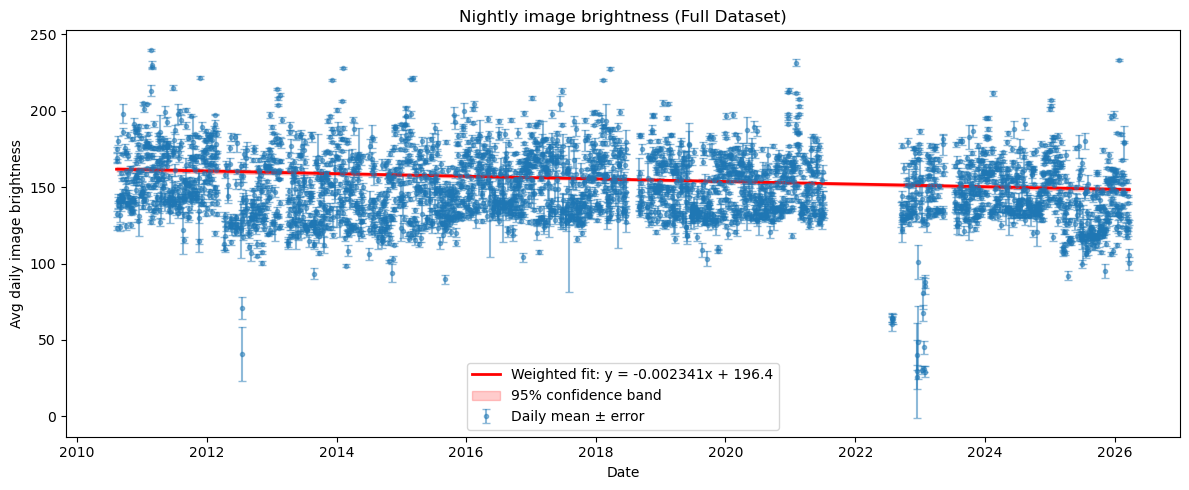

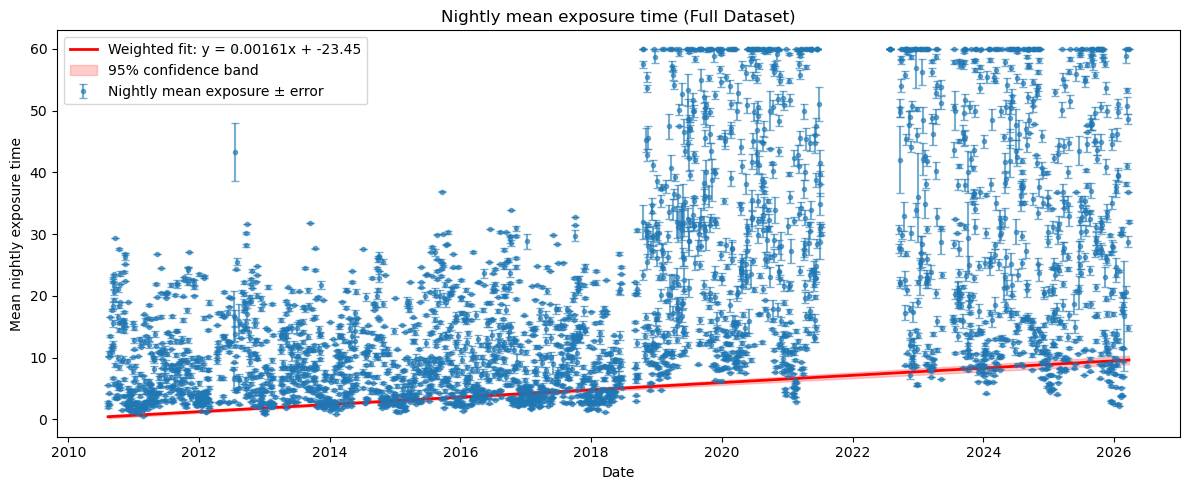

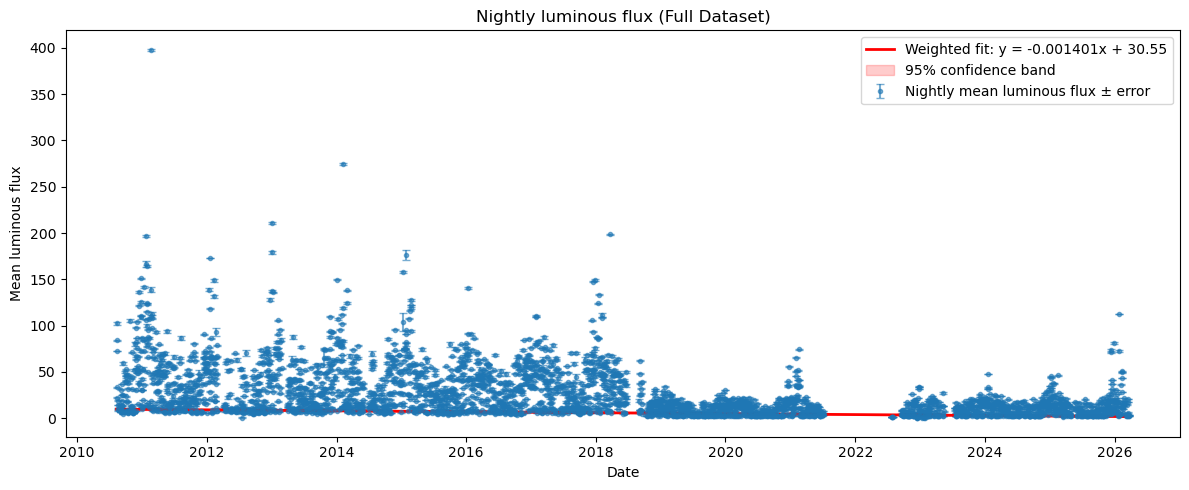

In [4]:
plot_brightness(enriched_df, "Full Dataset")
plot_exposure(enriched_df, "Full Dataset")
plot_luminous_flux(enriched_df, "Full Dataset")

In [5]:
recent_df = enriched_df[
        (pd.to_datetime(enriched_df["date"], format="%Y/%m/%d", errors="coerce").dt.year >= 2022)
]

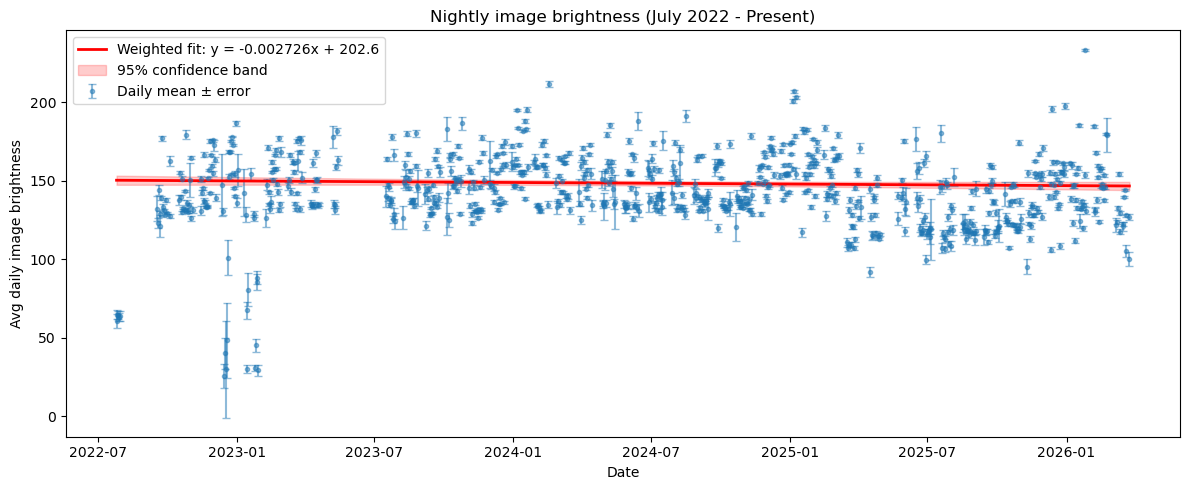

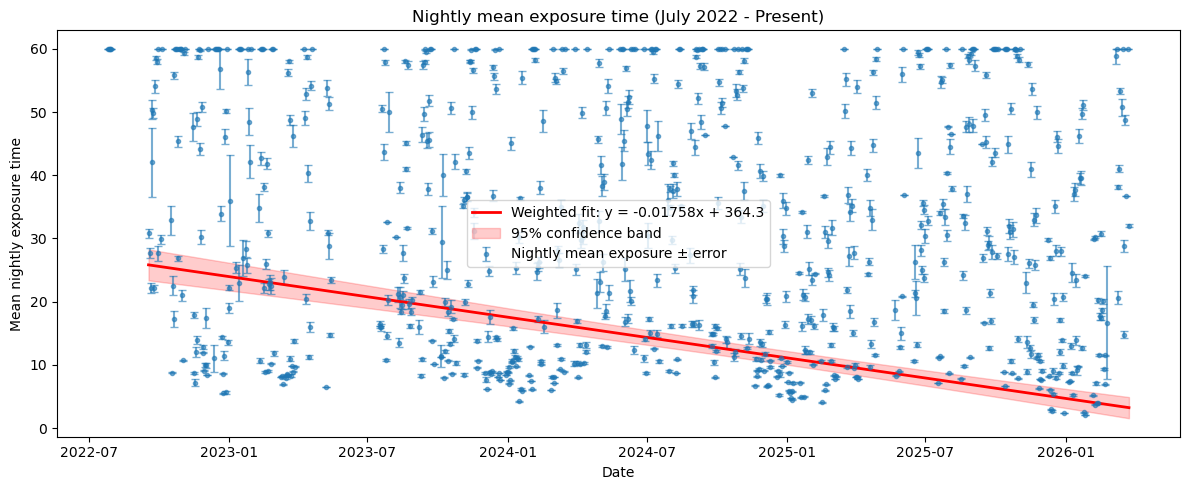

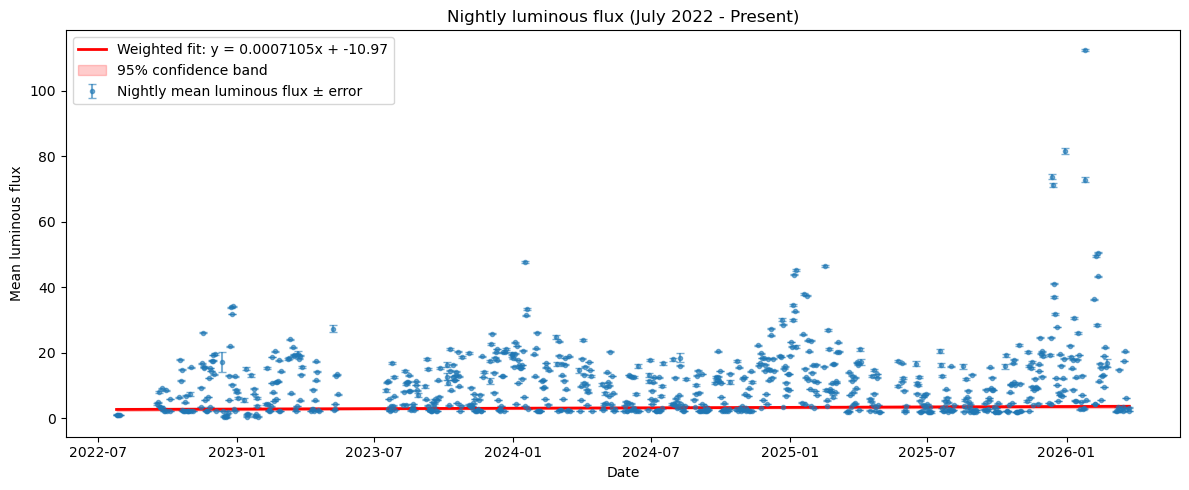

In [6]:
plot_brightness(recent_df, "July 2022 - Present")
plot_exposure(recent_df, "July 2022 - Present")
plot_luminous_flux(recent_df, "July 2022 - Present")

In [7]:
enriched_df

,date,time,exposure,filename,source_file,timestamp,image_paths,image_mean,image_sum,image_min,image_max,image_std,image_medians
8,2010/08/11,22:38:00,2.7883,000021274,2010-08.parquet,2010-08-11 22:38:00,/home/rainybyte/SomeSkyImages/2010-08/AllSkyIm...,157.789822,19822662,105,242,29.416727,156.0
9,2010/08/11,22:39:17,2.4769,000021275,2010-08.parquet,2010-08-11 22:39:17,/home/rainybyte/SomeSkyImages/2010-08/AllSkyIm...,159.858382,20082529,102,242,25.961395,158.0
10,2010/08/11,22:40:17,2.4769,000021276,2010-08.parquet,2010-08-11 22:40:17,/home/rainybyte/SomeSkyImages/2010-08/AllSkyIm...,163.385713,20525657,115,240,25.684782,161.0
11,2010/08/11,22:41:34,2.4769,000021277,2010-08.parquet,2010-08-11 22:41:34,/home/rainybyte/SomeSkyImages/2010-08/AllSkyIm...,166.985608,20977901,117,245,28.818942,163.0
12,2010/08/11,22:42:34,2.4769,000021278,2010-08.parquet,2010-08-11 22:42:34,/home/rainybyte/SomeSkyImages/2010-08/AllSkyIm...,158.146314,19867447,99,248,34.864647,154.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4,2026/03/25,05:40:08,32.0241,000422467,2026-03.parquet,2026-03-25 05:40:08,/home/rainybyte/SomeSkyImages/2026-03/AllSkyIm...,103.790141,13038844,51,221,19.991641,102.0
5,2026/03/25,05:40:41,32.0241,000422468,2026-03.parquet,2026-03-25 05:40:41,/home/rainybyte/SomeSkyImages/2026-03/AllSkyIm...,103.978412,13062496,57,235,19.158357,102.0
6,2026/03/25,05:41:34,36.3559,000422469,2026-03.parquet,2026-03-25 05:41:34,/home/rainybyte/SomeSkyImages/2026-03/AllSkyIm...,107.699698,13529990,56,232,20.021279,105.0
7,2026/03/25,05:42:11,36.3559,000422470,2026-03.parquet,2026-03-25 05:42:11,/home/rainybyte/SomeSkyImages/2026-03/AllSkyIm...,107.371680,13488782,59,253,21.015155,105.0


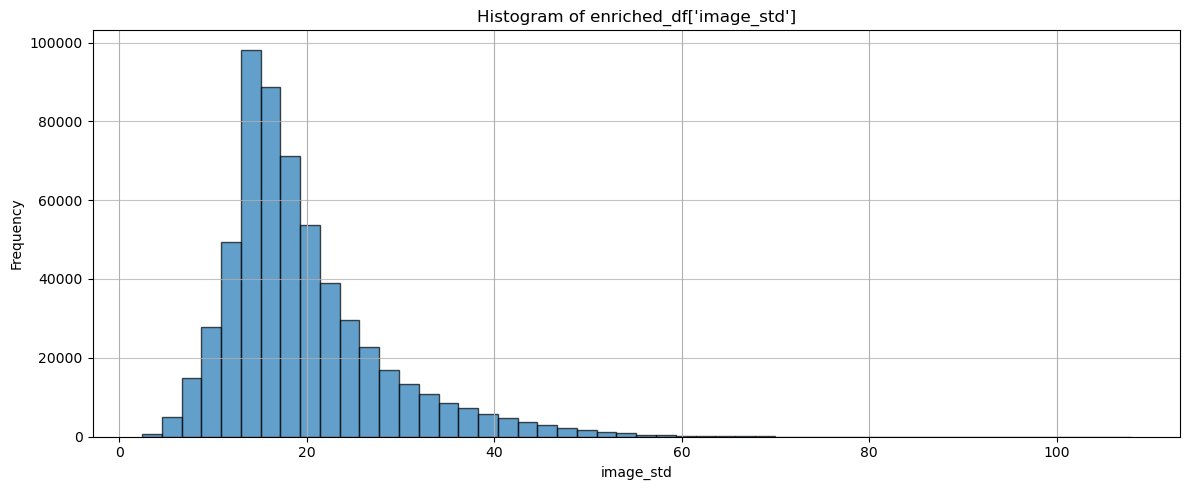

In [8]:
fig, ax = plt.subplots(figsize=(12, 5))
enriched_df['image_std'].hist(ax=ax, bins=50, edgecolor='black', alpha=0.7)
plt.title('Histogram of enriched_df[\'image_std\']')
plt.xlabel('image_std')
plt.ylabel('Frequency')
ax.grid(axis='y', alpha=0.75)
fig.tight_layout()

In [9]:
date_dt = pd.to_datetime(enriched_df["date"], format="%Y/%m/%d", errors="coerce")

preswitch_df = enriched_df[
    (date_dt.dt.year >= 2024) &
    (date_dt < pd.to_datetime("2025-03-21"))
]


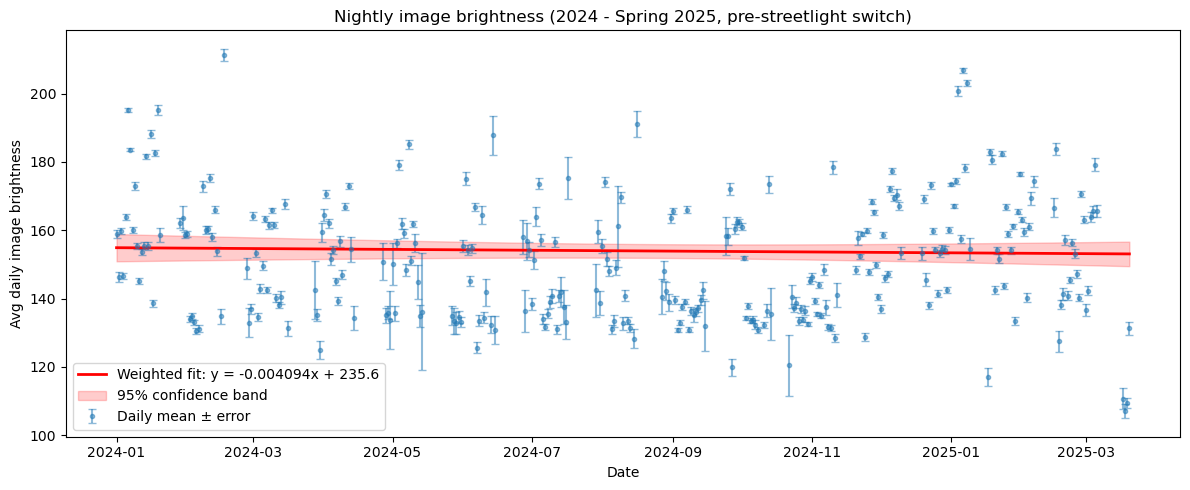

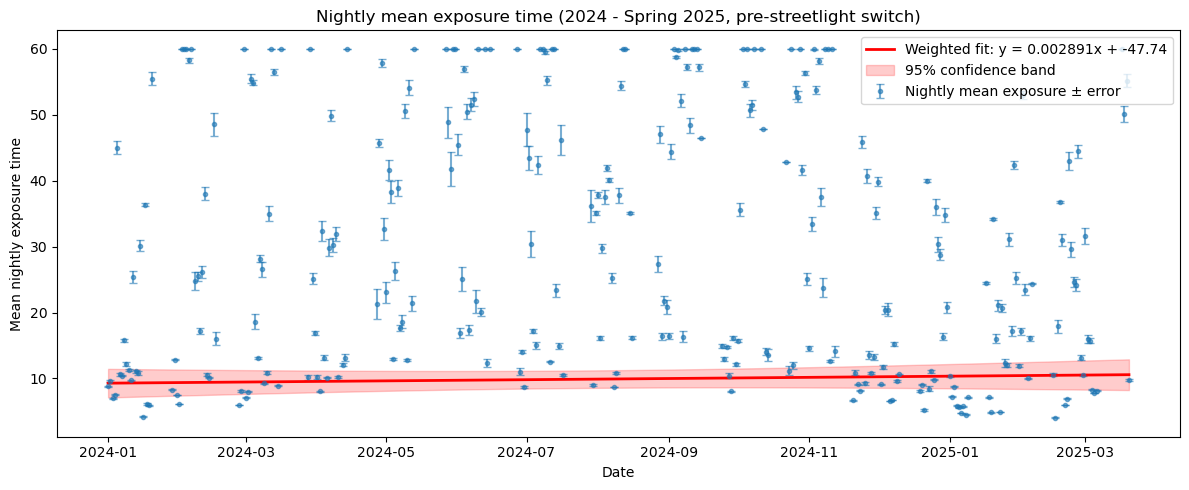

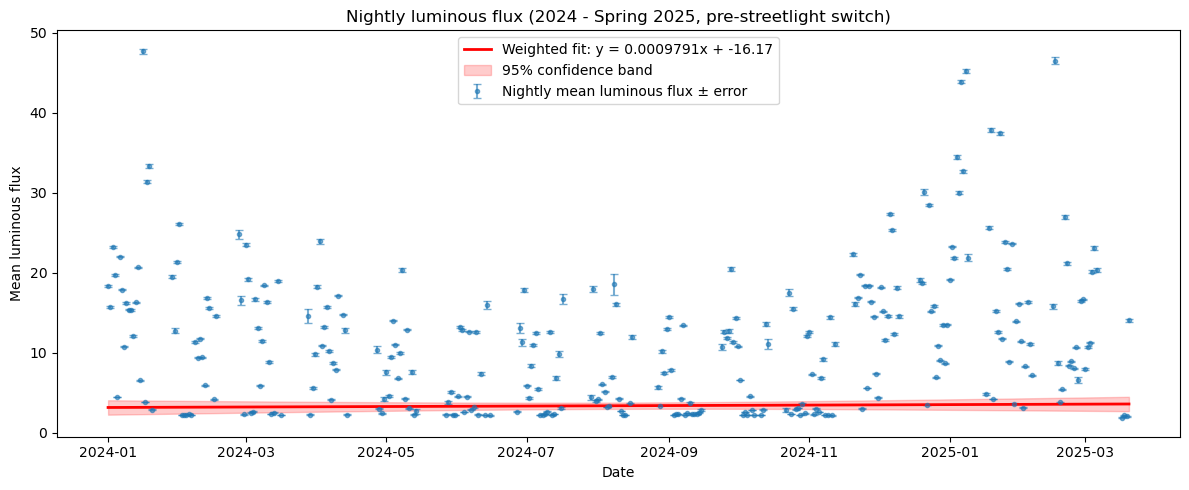

In [10]:
plot_brightness(preswitch_df, "2024 - Spring 2025, pre-streetlight switch")
plot_exposure(preswitch_df, "2024 - Spring 2025, pre-streetlight switch")
plot_luminous_flux(preswitch_df, "2024 - Spring 2025, pre-streetlight switch")

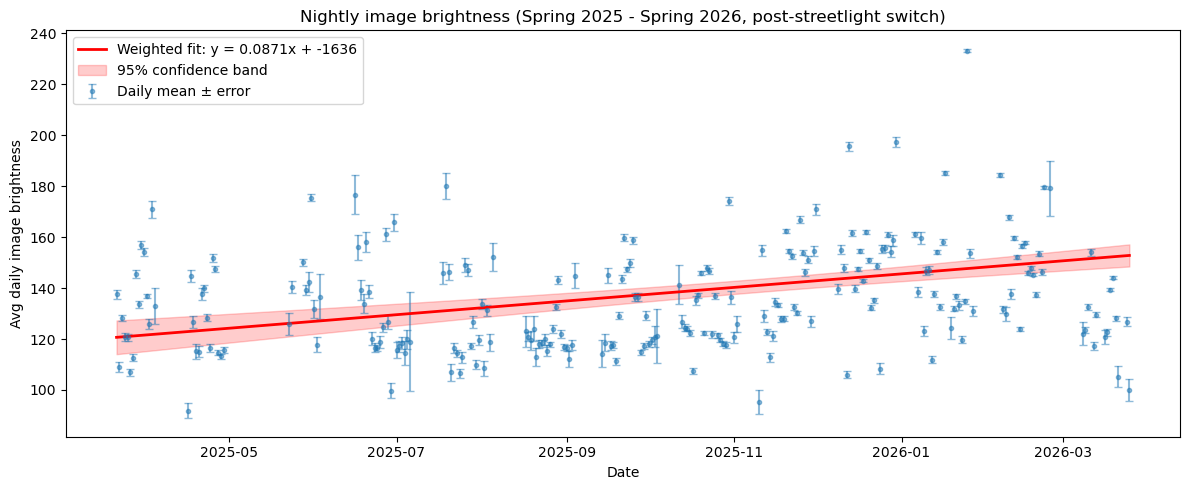

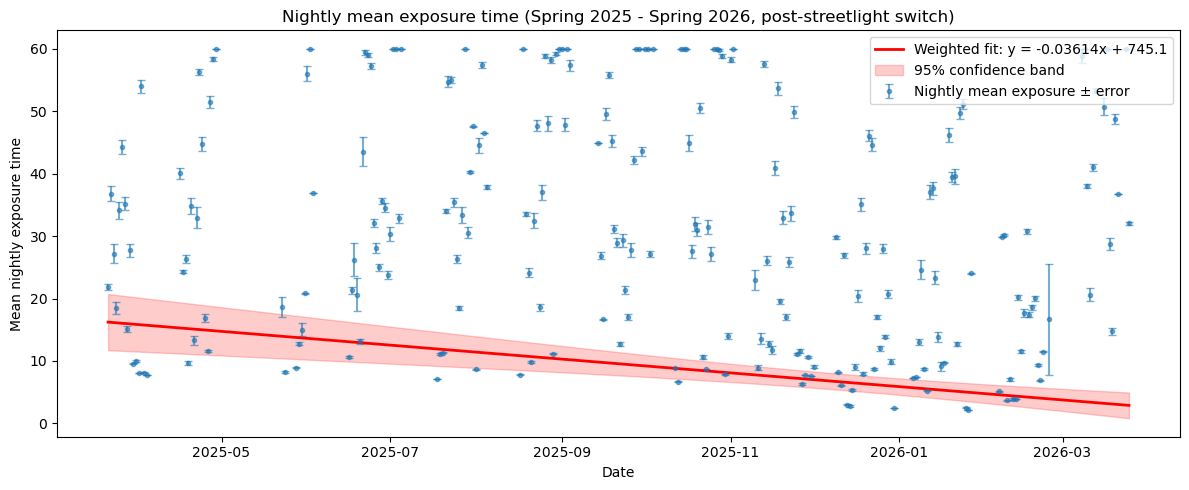

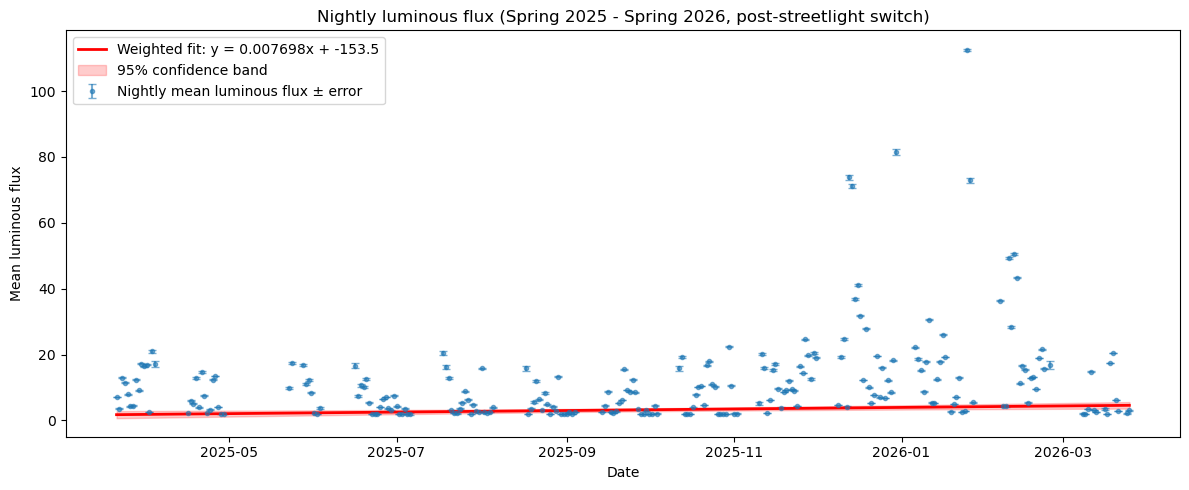

In [11]:
postswitch_df = enriched_df[
    (date_dt >= pd.to_datetime("2025-03-21"))
]
plot_brightness(postswitch_df, "Spring 2025 - Spring 2026, post-streetlight switch")
plot_exposure(postswitch_df, "Spring 2025 - Spring 2026, post-streetlight switch")
plot_luminous_flux(postswitch_df, "Spring 2025 - Spring 2026, post-streetlight switch")

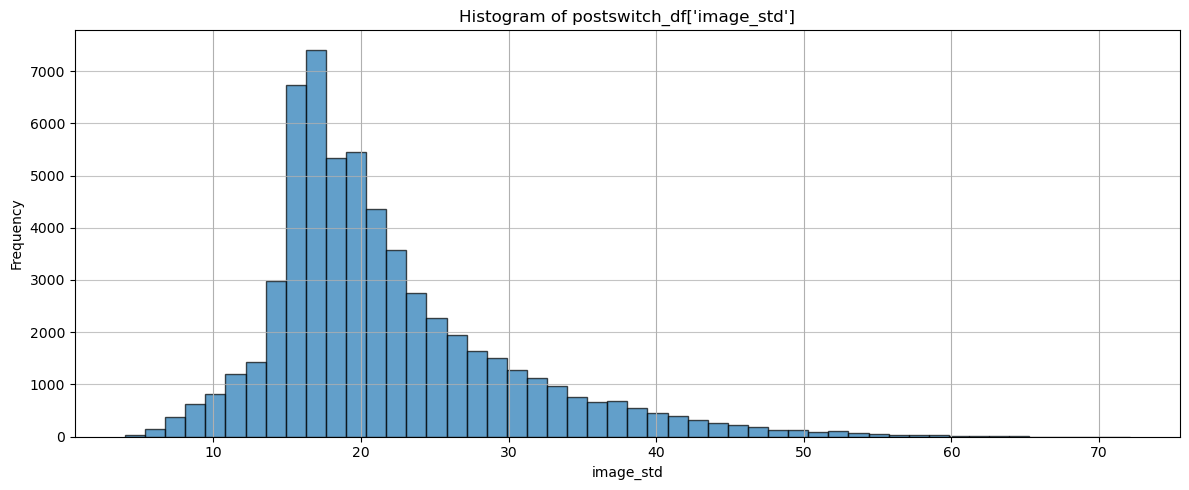

In [12]:
# postswitch_highfilter_df = postswitch_df[]
# postswitch_df[]

fig, ax = plt.subplots(figsize=(12, 5))
postswitch_df['image_std'].hist(ax=ax, bins=50, edgecolor='black', alpha=0.7)
plt.title('Histogram of postswitch_df[\'image_std\']')
plt.xlabel('image_std')
plt.ylabel('Frequency')
ax.grid(axis='y', alpha=0.75)
fig.tight_layout()

In [13]:
postswitch_highfilter_df = postswitch_df[
    (postswitch_df["image_medians"] >= 70)
    & (postswitch_df["image_medians"] < 200)
    & (postswitch_df["image_std"] < 42)
]
postswitch_highfilter_df

,date,time,exposure,filename,source_file,timestamp,image_paths,image_mean,image_sum,image_min,image_max,image_std,image_medians
10,2025/03/21,00:00:58,9.3262,000007376,2025-03.parquet,2025-03-21 00:00:58,/home/rainybyte/SomeSkyImages/2025-03/AllSkyIm...,143.175050,17986652,98,221,14.551748,142.0
11,2025/03/21,00:02:03,9.3262,000007377,2025-03.parquet,2025-03-21 00:02:03,/home/rainybyte/SomeSkyImages/2025-03/AllSkyIm...,139.629881,17541283,94,190,16.670539,136.0
12,2025/03/21,00:03:08,9.3262,000007378,2025-03.parquet,2025-03-21 00:03:08,/home/rainybyte/SomeSkyImages/2025-03/AllSkyIm...,135.755363,17054539,93,182,14.132885,132.0
13,2025/03/21,00:04:13,9.3262,000007379,2025-03.parquet,2025-03-21 00:04:13,/home/rainybyte/SomeSkyImages/2025-03/AllSkyIm...,136.472852,17144675,97,185,15.434762,131.0
14,2025/03/21,00:05:18,9.3262,000007380,2025-03.parquet,2025-03-21 00:05:18,/home/rainybyte/SomeSkyImages/2025-03/AllSkyIm...,137.840003,17316426,96,186,14.205064,132.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4,2026/03/25,05:40:08,32.0241,000422467,2026-03.parquet,2026-03-25 05:40:08,/home/rainybyte/SomeSkyImages/2026-03/AllSkyIm...,103.790141,13038844,51,221,19.991641,102.0
5,2026/03/25,05:40:41,32.0241,000422468,2026-03.parquet,2026-03-25 05:40:41,/home/rainybyte/SomeSkyImages/2026-03/AllSkyIm...,103.978412,13062496,57,235,19.158357,102.0
6,2026/03/25,05:41:34,36.3559,000422469,2026-03.parquet,2026-03-25 05:41:34,/home/rainybyte/SomeSkyImages/2026-03/AllSkyIm...,107.699698,13529990,56,232,20.021279,105.0
7,2026/03/25,05:42:11,36.3559,000422470,2026-03.parquet,2026-03-25 05:42:11,/home/rainybyte/SomeSkyImages/2026-03/AllSkyIm...,107.371680,13488782,59,253,21.015155,105.0


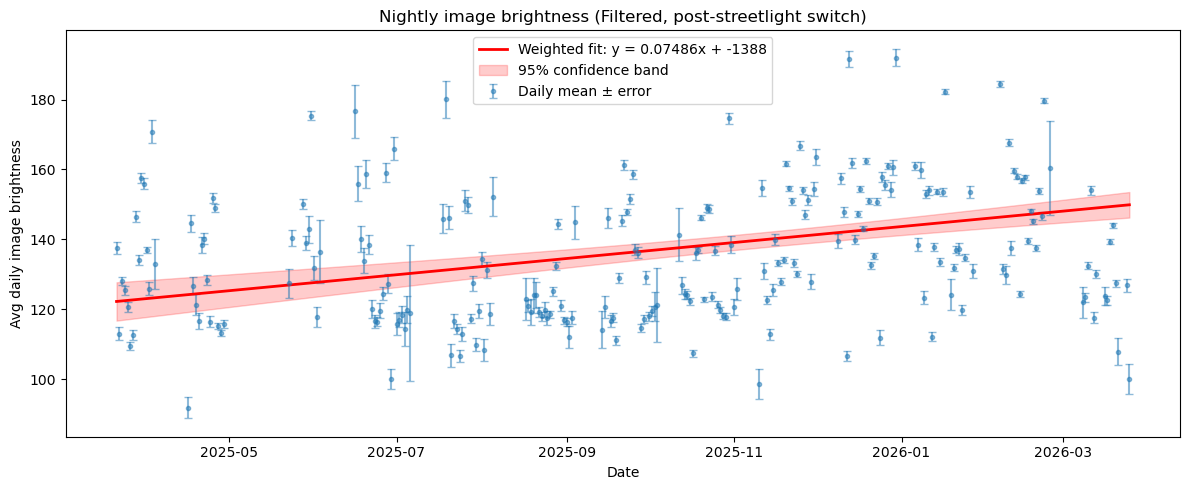

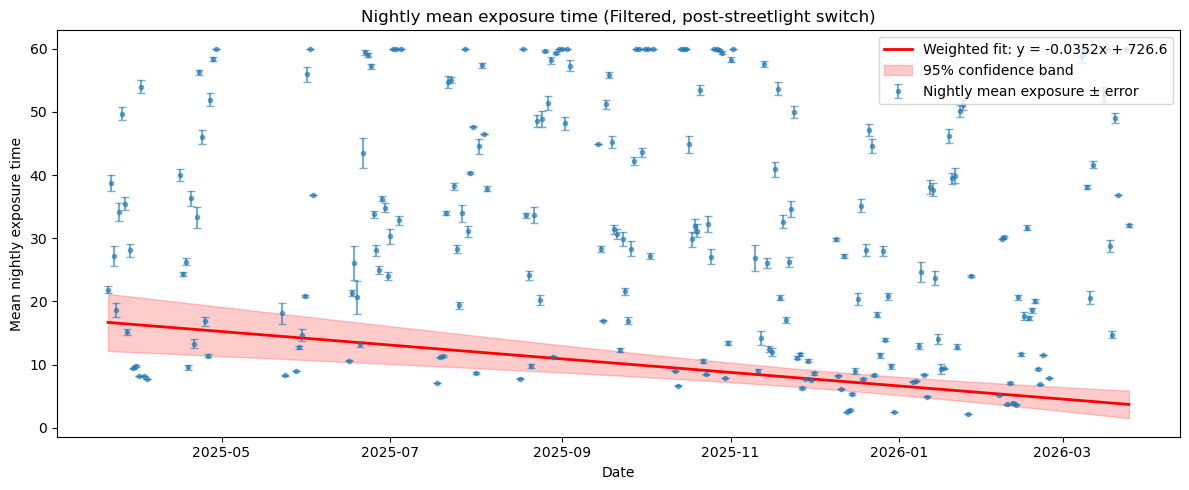

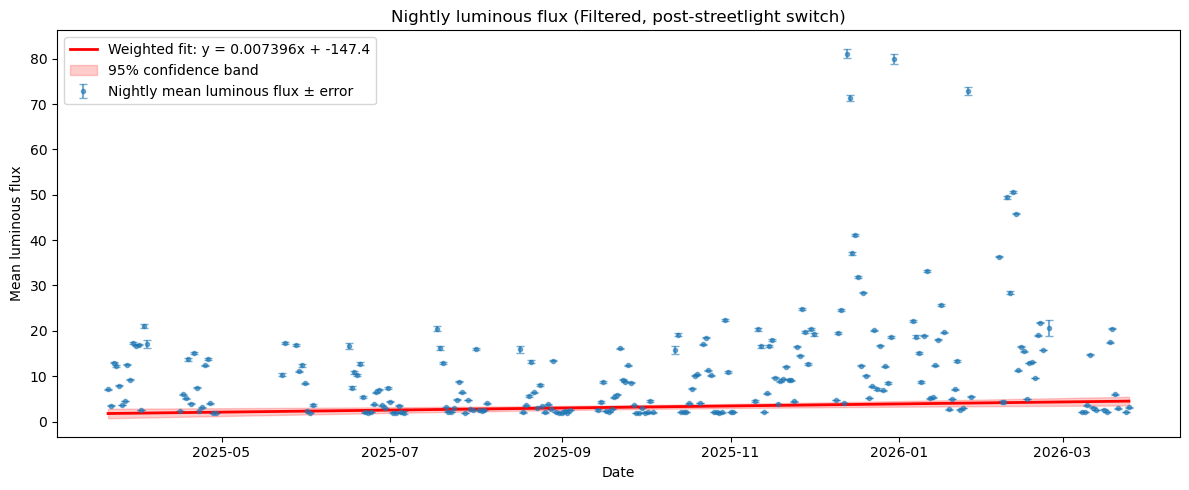

In [14]:
plot_brightness(postswitch_highfilter_df,    "Filtered, post-streetlight switch")
plot_exposure(postswitch_highfilter_df,      "Filtered, post-streetlight switch")
plot_luminous_flux(postswitch_highfilter_df, "Filtered, post-streetlight switch")